**import necessary libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split,cross_val_score, StratifiedKFold,StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)


**load the dataset**

In [57]:
df = pd.read_csv(r"C:\Users\sujee\Downloads\diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# EDA and data cleaning

In [58]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [59]:
df.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [61]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [62]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [63]:
# missing values
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [64]:
cols = ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]
for i in cols:
    print(i,(df[i]==0).sum())

Glucose 5
BloodPressure 35
SkinThickness 227
Insulin 374
BMI 11


In [65]:
df[cols] = df[cols].replace(0,np.nan)
df.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [66]:
df.fillna(df.mean(numeric_only=True),inplace=True)

In [67]:
print("Duplicate Rows:",df.duplicated().sum())

Duplicate Rows: 0


In [68]:
df["Outcome"].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [69]:
df["Outcome"].value_counts(normalize=True)*100

Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64

**Split features and target**

In [70]:
x=df.drop("Outcome",axis=1)
x

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148.0,72.0,35.00000,155.548223,33.6,0.627,50
1,1,85.0,66.0,29.00000,155.548223,26.6,0.351,31
2,8,183.0,64.0,29.15342,155.548223,23.3,0.672,32
3,1,89.0,66.0,23.00000,94.000000,28.1,0.167,21
4,0,137.0,40.0,35.00000,168.000000,43.1,2.288,33
...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.00000,180.000000,32.9,0.171,63
764,2,122.0,70.0,27.00000,155.548223,36.8,0.340,27
765,5,121.0,72.0,23.00000,112.000000,26.2,0.245,30
766,1,126.0,60.0,29.15342,155.548223,30.1,0.349,47


In [71]:
Y=df.drop("Outcome",axis=1)
Y

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148.0,72.0,35.00000,155.548223,33.6,0.627,50
1,1,85.0,66.0,29.00000,155.548223,26.6,0.351,31
2,8,183.0,64.0,29.15342,155.548223,23.3,0.672,32
3,1,89.0,66.0,23.00000,94.000000,28.1,0.167,21
4,0,137.0,40.0,35.00000,168.000000,43.1,2.288,33
...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.00000,180.000000,32.9,0.171,63
764,2,122.0,70.0,27.00000,155.548223,36.8,0.340,27
765,5,121.0,72.0,23.00000,112.000000,26.2,0.245,30
766,1,126.0,60.0,29.15342,155.548223,30.1,0.349,47


In [72]:
x[:5]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148.0,72.0,35.00000,155.548223,33.6,0.627,50
1,1,85.0,66.0,29.00000,155.548223,26.6,0.351,31
2,8,183.0,64.0,29.15342,155.548223,23.3,0.672,32
3,1,89.0,66.0,23.00000,94.000000,28.1,0.167,21
4,0,137.0,40.0,35.00000,168.000000,43.1,2.288,33


In [73]:
Y[:5]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148.0,72.0,35.00000,155.548223,33.6,0.627,50
1,1,85.0,66.0,29.00000,155.548223,26.6,0.351,31
2,8,183.0,64.0,29.15342,155.548223,23.3,0.672,32
3,1,89.0,66.0,23.00000,94.000000,28.1,0.167,21
4,0,137.0,40.0,35.00000,168.000000,43.1,2.288,33


In [74]:
X = df.drop(columns="Outcome")
y = df["Outcome"]

In [75]:

print("Shape Dataset -> ", df.shape)
print("Shape X -> ", X.shape)
print("Shape y -> ", y.shape)

Shape Dataset ->  (768, 9)
Shape X ->  (768, 8)
Shape y ->  (768,)


**Train Test Split**

In [76]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

**Scale the features**

In [77]:
scaler = StandardScaler()
scaler.fit(X_train)

,copy,True
,with_mean,True
,with_std,True


In [78]:
X_train_scaled = scaler.transform(X_train)
X_train_scaled

array([[-0.52639686, -1.25828206,  0.01321033, ...,  0.01501323,
        -0.49073479, -1.03594038],
       [ 1.58804586, -0.32735374,  0.8068672 , ..., -0.59935041,
         2.41502991,  1.48710085],
       [-0.82846011,  0.57032714, -2.17095414, ..., -0.52719904,
         0.54916055, -0.94893896],
       ...,
       [ 1.8901091 , -0.69307558,  1.13773624, ...,  1.91151712,
         1.981245  ,  0.44308379],
       [-1.13052335,  0.63682202,  0.01321033, ...,  1.44974838,
        -0.78487662, -0.33992901],
       [-1.13052335,  0.10486298,  1.96490883, ..., -1.42187598,
        -0.61552223, -1.03594038]], shape=(614, 8))

In [79]:
x_test_scaled = scaler.transform(X_test)


In [80]:
X_test_scaled = scaler.transform(X_test)

In [81]:
print(X_train.shape)
print(X_test.shape)



(614, 8)
(154, 8)


In [82]:
print(X_train.dtypes)
print(X_test.dtypes)

Pregnancies                   int64
Glucose                     float64
BloodPressure               float64
SkinThickness               float64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
dtype: object
Pregnancies                   int64
Glucose                     float64
BloodPressure               float64
SkinThickness               float64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
dtype: object


**Model Training (Logistic Regression)**

In [83]:
model = LogisticRegression()
model.fit(X_train_scaled,y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


**Predictions**

In [84]:
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

y_test_prob = model.predict_proba(X_test_scaled)[:, 1]


In [85]:
train_pred = model.predict(X_train_scaled)
test_pred = model.predict(x_test_scaled)
prob_train = model.predict_proba(X_train_scaled)
prob_test = model.predict_proba(x_test_scaled)

In [86]:
train_pred

array([0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0,
       1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0,

In [87]:
test_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0])

In [88]:
prob_train

array([[0.94558996, 0.05441004],
       [0.59111884, 0.40888116],
       [0.67958432, 0.32041568],
       ...,
       [0.36167139, 0.63832861],
       [0.43702201, 0.56297799],
       [0.94263217, 0.05736783]], shape=(614, 2))

In [89]:
prob_test

array([[0.71728313, 0.28271687],
       [0.83606362, 0.16393638],
       [0.89460661, 0.10539339],
       [0.84634265, 0.15365735],
       [0.54099098, 0.45900902],
       [0.55368795, 0.44631205],
       [0.98575091, 0.01424909],
       [0.62421038, 0.37578962],
       [0.42665813, 0.57334187],
       [0.24360418, 0.75639582],
       [0.77865771, 0.22134229],
       [0.11129996, 0.88870004],
       [0.60647622, 0.39352378],
       [0.72132736, 0.27867264],
       [0.92391448, 0.07608552],
       [0.59547239, 0.40452761],
       [0.88852602, 0.11147398],
       [0.92581118, 0.07418882],
       [0.28696241, 0.71303759],
       [0.4276886 , 0.5723114 ],
       [0.81321167, 0.18678833],
       [0.92363217, 0.07636783],
       [0.4879827 , 0.5120173 ],
       [0.90609914, 0.09390086],
       [0.441299  , 0.558701  ],
       [0.11975457, 0.88024543],
       [0.89419898, 0.10580102],
       [0.97085302, 0.02914698],
       [0.73740088, 0.26259912],
       [0.89341073, 0.10658927],
       [0.

**Evaluation Metric (Train & Test)**

In [90]:
confusion_matrix(y_test,test_pred)

array([[82, 17],
       [21, 34]])

In [91]:
accuracy_score(y_test,test_pred)

0.7532467532467533

In [92]:
precision_score(y_test,test_pred)

0.6666666666666666

In [93]:
recall_score(y_test,test_pred)

0.6181818181818182

In [94]:
f1_score(y_test,test_pred)

0.6415094339622641

In [95]:
roc_auc_score(y_test,test_pred)

0.7232323232323232

In [96]:
def evaluate(title, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)   
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    print(title)
    print(f"  Accuracy: {acc:.2%}")
    print(f"  Precision: {prec:.2%}")
    print(f"  Recall: {rec:.2%}")
    print(f"  F1-score: {f1:.2%}")
    print()

In [97]:
evaluate("TRAIN",y_train,train_pred)
evaluate("TEST",y_test,test_pred)

TRAIN
  Accuracy: 77.20%
  Precision: 71.86%
  Recall: 56.34%
  F1-score: 63.16%

TEST
  Accuracy: 75.32%
  Precision: 66.67%
  Recall: 61.82%
  F1-score: 64.15%



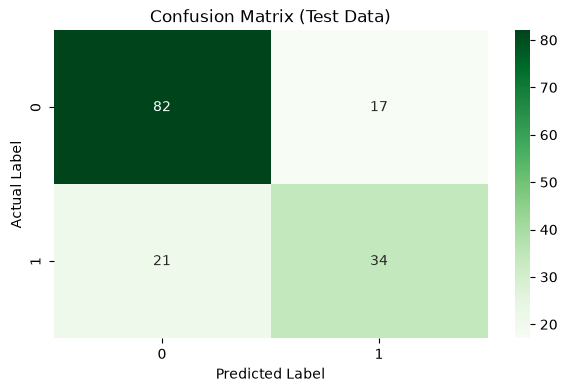

In [103]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, test_pred)

plt.figure(figsize=(7, 4))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Greens",
            xticklabels=["0", "1"],
            yticklabels=["0", "1"])

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix (Test Data)")
plt.show()